In [3]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x)//2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3])
df["loss_last_3"] = df["val_loss"].apply(lambda x: x[-4])

df["loss_acceleration"] = df["val_loss"].apply(
    lambda c: (c[-1] - c[-2]) - (c[-2] - c[-3])
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

# -------- GAP FEATURES --------

def build_gap(train, val):
    train = np.array(train)
    val = np.array(val)

    gap = train - val

    return pd.Series({
        "gap_last": gap[-1],
        "gap_growth": gap[-1] - gap[0],
        "gap_std": np.std(gap)
    })

gap_df = df.apply(
    lambda r: build_gap(r["train_loss"], r["val_loss"]),
    axis=1
)

df = pd.concat([df, gap_df], axis=1)

# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

df = df.drop(columns=[
    "val_loss",
    "train_loss",
    "val_acc",
    "index",
    "seed"
])

# -------- FEATURES --------

X = df.drop(columns=[
    "loss_end",
    "overfitting",
    "imbalance",
    "train_acc",
    "test_acc",
    "model",
    "shift_type"
])

y = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             epoch     test_acc  overfitting   train_size    imbalance  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean     34.793290     0.753080     0.500000  1264.285714     0.500000   
std      23.561086     0.156870     0.500068  1652.649140     0.500068   
min       6.000000     0.097500     0.000000    50.000000     0.000000   
25%      21.000000     0.639775     0.000000   100.000000     0.000000   
50%      28.000000     0.769250     0.500000   500.000000     0.500000   
75%      40.000000     0.889625     1.000000  2000.000000     1.000000   
max     210.000000     0.982500     1.000000  5000.000000     1.000000   

        loss_start     loss_mid  loss_last_1  loss_last_2  loss_last_3  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean      1.600830     0.721397     0.707434     0.705634     0.703141   
std       0.706650     0.507957     0.502616     0.500519     0.497128   
min       0.188716     0.047854     0

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()


mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Epoch 1/100


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8858 - mae: 0.7274 - val_loss: 0.0538 - val_mae: 0.1647
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3903 - mae: 0.4838 - val_loss: 0.0937 - val_mae: 0.2284
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3206 - mae: 0.4370 - val_loss: 0.0986 - val_mae: 0.2567
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2616 - mae: 0.3898 - val_loss: 0.0919 - val_mae: 0.2466
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2298 - mae: 0.3680 - val_loss: 0.0911 - val_mae: 0.2485
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2122 - mae: 0.3550 - val_loss: 0.0863 - val_mae: 0.2360
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1872 - mae: 0.3319 - val_loss: 0.0780 - val_mae: 0.2225
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1807 - mae: 0.3208 - val_loss: 0.0671 - val_mae: 0.1997
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1595 - mae: 0.3

In [36]:
from tensorflow.keras.callbacks import Callback


class SmartEarlyStoppingMultiStep(Callback):
    def __init__(
        self,
        model_meta,
        train_size,
        future_steps=3,
        shift_noise=False,
        min_epochs=5,
        threshold_increase=1e-3,
    ):
        super().__init__()
        self.should_stop = False
        self.model_meta = model_meta
        self.train_size = train_size
        self.shift_noise = shift_noise
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.threshold_increase = threshold_increase

        self.train_loss = []
        self.val_loss = []

        self.feature_order = [
            'epoch', 'train_size', 'loss_start', 'loss_mid', 'loss_last_1',
            'loss_last_2', 'loss_last_3', 'loss_acceleration', 'loss_growth',
            'loss_stability', 'gap_last', 'gap_growth', 'gap_std'
        ]

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if train_loss is None or val_loss is None:
            return

        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)

        if len(self.val_loss) < self.min_epochs:
            return

        preds = self.predict_future(epoch)

        # --- тренд по будущим значениям ---
        trend = np.polyfit(range(len(preds)), preds, 1)[0]

        # --- условие остановки ---
        if (
            trend > 0
            and np.mean(preds) > self.val_loss[-1] + self.threshold_increase
        ):
            print(f"Expected future increase → stopping at epoch {epoch}")
            # self.model.stop_training = True
            self.should_stop = True


        print(
            f"epoch={epoch} val_loss={val_loss:.4f} "
            f"future={[round(x,4) for x in preds]} trend={trend:.6f}"
        )

    # 🔥 ключевая часть
    def predict_future(self, epoch):
        val = list(self.val_loss[-10:])
        train = list(self.train_loss[-10:])

        preds = []

        for step in range(self.future_steps):
            val_np = np.array(val[-10:])
            train_np = np.array(train[-10:])
            min_len = min(len(val_np), len(train_np))

            val_np = val_np[-min_len:]
            train_np = train_np[-min_len:]

            if min_len < 5:
                pad = 5 - min_len
                val_np = np.pad(val_np, (pad, 0), "edge")
                train_np = np.pad(train_np, (pad, 0), "edge")

            gap = train_np - val_np

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,

                "loss_start": val_np[0],
                "loss_mid": val_np[len(val_np)//2],
                "loss_last_1": val_np[-1],
                "loss_last_2": val_np[-2],
                "loss_last_3": val_np[-3],

                "loss_acceleration": val_np[-1] - 2 * val_np[-2] + val_np[-3],
                "loss_growth": val_np[-1] - val_np[0],
                "loss_stability": np.std(val_np),

                "gap_last": gap[-1],
                "gap_growth": gap[-1] - gap[0],
                "gap_std": np.std(gap),
            }

            df = pd.DataFrame([row])[self.feature_order]

            # --- предсказание Δloss ---
            pred_delta = self.model_meta.predict(df)[0]

            # 🔥 перевод в абсолютный loss
            next_val = val[-1] * (1 + pred_delta)

            preds.append(next_val)

            # --- обновляем последовательность ---
            val.append(next_val)

            # train можно не трогать (достаточно хорошо работает)

        return preds


class EarlyStoppingWrapper(Callback):
    def __init__(self, patience=5):
        super().__init__()
        self.es = EarlyStopping(patience=patience, restore_best_weights=False)
        self.should_stop = False
        self.stop_epoch = None

    def set_model(self, model):
        self.es.set_model(model)
        super().set_model(model)

    def on_epoch_end(self, epoch, logs=None):
        self.es.on_epoch_end(epoch, logs)

        if self.model.stop_training:
            self.should_stop = True
            self.stop_epoch = epoch
            self.model.stop_training = False  # ❗ отменяем остановку


class CombinedEarlyStopping(Callback):
    def __init__(self, smart_cb, early_cb):
        super().__init__()
        self.smart_cb = smart_cb
        self.early_cb = early_cb

        self.history = {
            "smart_trigger": [],
            "early_trigger": [],
            "final_stop_epoch": None
        }

    def on_epoch_end(self, epoch, logs=None):
        # логируем сигналы
        self.history["smart_trigger"].append(self.smart_cb.should_stop)
        self.history["early_trigger"].append(self.early_cb.should_stop)

        # 🔥 условие: оба согласны
        if self.smart_cb.should_stop and self.early_cb.should_stop:
            print(f"Both callbacks agree → stopping at epoch {epoch}")
            self.history["final_stop_epoch"] = epoch
            self.model.stop_training = True




In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)
def build_mlp(hidden_units=128, l2=0.0):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    return model

def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),  # вход
        # layers.Dense(32, activation="relu"),     # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")   # выходной слой
    ])
    return model

Epoch 1/200


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3450 - loss: 2.0101 - val_accuracy: 0.6400 - val_loss: 1.6266
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 1.3031 - val_accuracy: 0.7700 - val_loss: 1.1902
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8325 - loss: 0.9463 - val_accuracy: 0.8200 - val_loss: 0.9767
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8675 - loss: 0.7457 - val_accuracy: 0.8200 - val_loss: 0.8569
Epoch 5/200
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7000 - loss: 0.8232Expected future increase → stopping at epoch 4
epoch=4 val_loss=0.7809 future=[np.float64(0.7874), np.float64(0.8591), np.float64(0.9174)] trend=0.064964
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8825 - loss: 0.6254 - val_accuracy: 0.8200 - val_loss: 0.7809
Epoch 6/200
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9000 - loss: 0.3931Expected future increase → stopping at epoch 5
epoch=5 val_loss=0

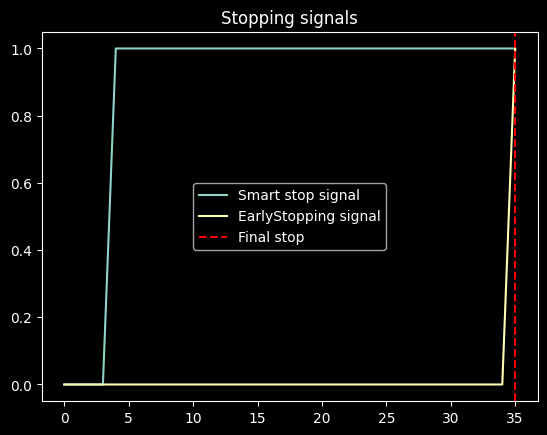

In [39]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    500
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

early_stop = EarlyStoppingWrapper(patience=5)
early_stop.set_model(model_mnist)
combined = CombinedEarlyStopping(smart_stop, early_stop)

model_mnist.fit(
    X_train[:500],
    y_train[:500],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop, early_stop, combined]
)

import matplotlib.pyplot as plt

smart = combined.history["smart_trigger"]
early = combined.history["early_trigger"]

plt.plot(smart, label="Smart stop signal")
plt.plot(early, label="EarlyStopping signal")

plt.axvline(combined.history["final_stop_epoch"], color="red", linestyle="--", label="Final stop")

plt.legend()
plt.title("Stopping signals")
plt.show()

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def run_experiment(X, y, train_size, callback):

    model = build_mlp_overfit()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=10,
        verbose=0,
        callbacks=[callback]
    )

    return history

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

def run_training(X, y, train_size, callback):

    model = build_mlp_overfit()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [63]:
sizes = [500, 1000, 2000]
runs = 5

results = []

for size in sizes:

    for r in range(runs):

        early = EarlyStopping(
            monitor="val_loss",
            patience=5
        )

        smart = SmartEarlyStopping(
            model_reg,
            size
        )

        res_early = run_training(X_train, y_train, size, early)
        res_smart = run_training(X_train, y_train, size, smart)

        results.append({
            "train_size": size,
            "run": r,

            "early_epochs": res_early["epochs"],
            "early_acc": res_early["test_acc"],
            "early_loss": res_early["test_loss"],

            "smart_epochs": res_smart["epochs"],
            "smart_acc": res_smart["test_acc"],
            "smart_loss": res_smart["test_loss"],
        })

df = pd.DataFrame(results)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0870,
Expected metric increase → stopping 0.0870
epoch=3 val_loss=0.9103 pred=0.0870 0.02806


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0376,
Expected metric increase → stopping 0.0376
epoch=3 val_loss=0.7210 pred=0.0376 0.02806


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

predicted next loss: 0.0418,
Expected metric increase → stopping 0.0418
epoch=3 val_loss=0.3777 pred=0.0418 0.02806


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0883,
Expected metric increase → stopping 0.0883
epoch=3 val_loss=0.3332 pred=0.0883 0.02806


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0215,
epoch=3 val_loss=0.3672 pred=0.0215 0.02806
predicted next loss: -0.0763,
epoch=4 val_loss=0.3230 pred=-0.0763 0.02806
predicted next loss: -0.0651,
epoch=5 val_loss=0.2990 pred=-0.0651 0.02806
predicted next loss: -0.0668,
epoch=6 val_loss=0.2952 pred=-0.0668 0.02806
predicted next loss: -0.0821,
epoch=7 val_loss=0.2757 pred=-0.0821 0.02806
predicted next loss: -0.0243,
epoch=8 val_loss=0.2722 pred=-0.0243 0.02806
predicted next loss: -0.0057,
epoch=9 val_loss=0.2822 pred=-0.0057 0.02806
predicted next loss: -0.0840,
epoch=10 val_loss=0.2685 pred=-0.0840 0.02806
predicted next loss: -0.0013,
epoch=11 val_loss=0.2536 pred=-0.0013 0.02806
predicted next loss: 0.0182,
epoch=12 val_loss=0.2469 pred=0.0182 0.02806
predicted next loss: 0.0422,
Expected metric increase → stopping 0.0422
epoch=13 val_loss=0.2625 pred=0.0422 0.02806


            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
500           0.81500    0.74204    0.617503    0.922144          20.6   
1000          0.86754    0.83072    0.443645    0.593664          15.6   
2000          0.88696    0.87540    0.413161    0.431457          19.0   

            smart_epochs  diff_epochs  
train_size                             
500                  4.0         16.6  
1000                 4.0         11.6  
2000                 8.0         11.0  


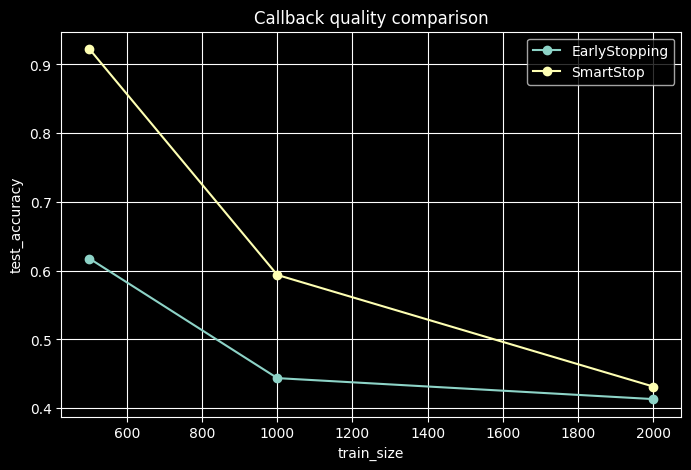

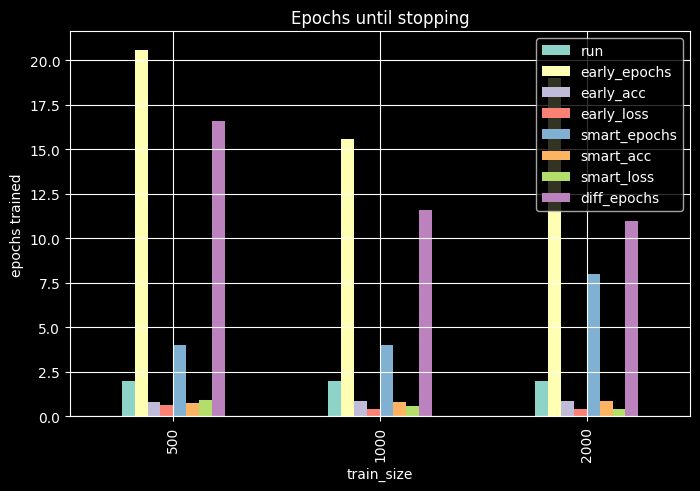

In [64]:
df['diff_epochs'] = df['early_epochs'] - df['smart_epochs']
summary = df.groupby("train_size").mean()

print(summary[[
    "early_acc",
    "smart_acc",
    "early_loss",
    "smart_loss",
    "early_epochs",
    "smart_epochs", "diff_epochs"
]])
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")

plt.xlabel("train_size")
plt.ylabel("test_accuracy")
plt.title("Callback quality comparison")

plt.legend()
plt.grid()

plt.show()
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(8,5))

plt.ylabel("epochs trained")
plt.title("Epochs until stopping")
plt.grid()

plt.show()

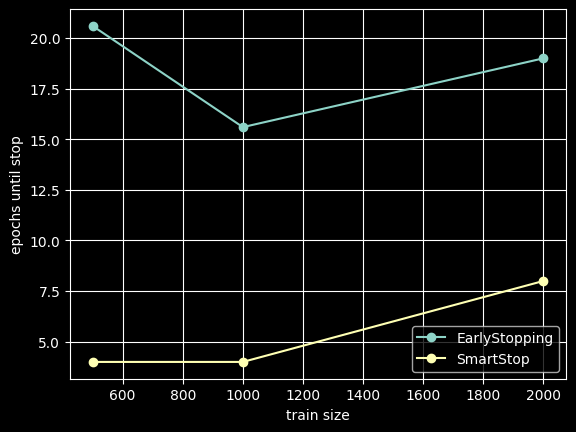

In [65]:
import matplotlib.pyplot as plt

plt.plot(summary.index, summary["early_epochs"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_epochs"], marker="o", label="SmartStop")

plt.xlabel("train size")
plt.ylabel("epochs until stop")

plt.legend()
plt.grid()

plt.show()